In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [15]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 20.8 MB/s eta 0:00:00


**Imports**

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)


**Load CSVs**

In [4]:
BASE_RESULTS = "/content/drive/MyDrive/cyber_fusion_models/results"

IMAGE_CSV   = os.path.join(BASE_RESULTS, "image_results.csv")
TEXT_CSV    = os.path.join(BASE_RESULTS, "text_results.csv")
TABULAR_CSV = os.path.join(BASE_RESULTS, "tabular_results.csv")

FUSION_OUT = os.path.join(BASE_RESULTS, "fusion_outputs")
os.makedirs(FUSION_OUT, exist_ok=True)


In [5]:
image_df   = pd.read_csv(IMAGE_CSV)
text_df    = pd.read_csv(TEXT_CSV)
tabular_df = pd.read_csv(TABULAR_CSV)

print("IMAGE COLUMNS :", image_df.columns.tolist())
print("TEXT  COLUMNS :", text_df.columns.tolist())
print("TAB   COLUMNS :", tabular_df.columns.tolist())


IMAGE COLUMNS : ['id', 'y_true', 'prob']
TEXT  COLUMNS : ['id', 'y_true', 'prob']
TAB   COLUMNS : ['id', 'y_true', 'prob']


In [6]:
common_ids = (
    set(image_df["id"]) &
    set(text_df["id"]) &
    set(tabular_df["id"])
)

print("Samples used for fusion:", len(common_ids))


Samples used for fusion: 94


In [7]:
img_prob = dict(zip(image_df["id"], image_df["prob"]))
txt_prob = dict(zip(text_df["id"], text_df["prob"]))
tab_prob = dict(zip(tabular_df["id"], tabular_df["prob"]))
labels   = dict(zip(image_df["id"], image_df["y_true"]))


In [21]:
def confidence_weighted_fusion(
    probs: dict,
    weights: dict,
    threshold: float = 0.5
):
    """
    probs   : {"image": p, "text": p, "tabular": p}
    weights : {"image": w, "text": w, "tabular": w}
    """

    available = {k: v for k, v in probs.items() if v is not None}

    # ---- Case 1: Single modality → bypass fusion ----
    if len(available) == 1:
        final_prob = list(available.values())[0]

    # ---- Case 2: Multiple modalities → weighted average ----
    else:
        num = sum(weights[k] * available[k] for k in available)
        den = sum(weights[k] for k in available)
        final_prob = num / den

    final_pred = int(final_prob >= threshold)
    return final_prob, final_pred


In [56]:
# Extract Optuna results correctly
optuna_params = {
    "image": 0.7929360804527206,
    "text":  0.10669406850527811,
    "tabular": 0.21709403660885632
}

threshold = 0.45999999999999996

fused_probs, fused_preds, y_true = [], [], []

for sid in sorted(common_ids):
    prob, pred = confidence_weighted_fusion(
        {
            "image": img_prob.get(sid),
            "text":  txt_prob.get(sid),
            "tabular": tab_prob.get(sid)
        },
        optuna_params,
        threshold
    )

    fused_probs.append(prob)
    fused_preds.append(pred)
    y_true.append(labels[sid])


In [57]:
fused_probs = []
fused_preds = []
y_true      = []

for sid in sorted(common_ids):
    p_img = img_prob[sid]
    p_txt = txt_prob[sid]
    p_tab = tab_prob[sid]

    prob, pred = adaptive_confidence_fusion(p_img, p_txt, p_tab)

    fused_probs.append(prob)
    fused_preds.append(pred)
    y_true.append(labels[sid])


In [58]:
fusion_df = pd.DataFrame({
    "id": sorted(common_ids),
    "fused_prob": fused_probs,
    "fused_pred": fused_preds,
    "y_true": y_true
})

fusion_df.to_csv(f"{FUSION_OUT}/fusion_results.csv", index=False)
print("Fused Predictions:",fused_preds)
print("Fused Probabilities:",fused_probs)


Fused Predictions: [1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1]
Fused Probabilities: [0.5499972114637514, 0.7082119539552182, 0.738730766311935, 0.26030652652572317, 0.7211589986468335, 0.6164872340300992, 0.3266532927932126, 0.28684202227151834, 0.19569748003036444, 0.7308717509946129, 0.2613997088657795, 0.5598056973298734, 0.5240885104419818, 0.896275745034035, 0.9290272988849196, 0.6841965119477579, 0.5072584508941379, 0.2886889098854382, 0.5210389052808204, 0.5398013074138029, 0.6058810212615343, 0.9128290218241958, 0.08220958596608537, 0.36465913896790303, 0.9289407803826369, 0.8102654494101396, 0.42676285751118487, 0.23970638222635757, 0.20003964560349163, 0.22560026349517717, 0.40533613834973936, 0.7298094253102985, 0.6066313679681793, 0.308590

In [33]:
import optuna
from sklearn.metrics import roc_auc_score

def fusion_objective(trial):
    weights = {
        "image": trial.suggest_float("w_img", 0.1, 1.0),
        "text":  trial.suggest_float("w_txt", 0.1, 1.0),
        "tabular": trial.suggest_float("w_tab", 0.1, 1.0),
    }

    threshold = trial.suggest_float("threshold", 0.1, 0.9)

    fused_probs = []
    true_labels = []

    for sid in common_ids:
        prob, _ = confidence_weighted_fusion(
            {
                "image": img_prob.get(sid),
                "text":  txt_prob.get(sid),
                "tabular": tab_prob.get(sid)
            },
            weights,
            threshold
        )

        fused_probs.append(prob)
        true_labels.append(labels[sid])

    return roc_auc_score(true_labels, fused_probs)


In [50]:
from sklearn.metrics import accuracy_score, f1_score

best_acc, best_t = 0, None

for t in np.linspace(0.1, 0.9, 81):
    preds = (np.array(fused_probs) >= t).astype(int)
    acc = accuracy_score(y_true, preds)
    if acc > best_acc:
        best_acc = acc
        best_t = t

print("Best Accuracy:", best_acc)
print("Best Threshold:", best_t)


Best Accuracy: 0.8404255319148937
Best Threshold: 0.45999999999999996


In [51]:
study = optuna.create_study(direction="maximize")
study.optimize(fusion_objective, n_trials=50)

print("Best AUC:", study.best_value)
print("Best Params:", study.best_params)


[I 2025-12-22 06:08:59,250] A new study created in memory with name: no-name-a4e13f51-e3a3-4292-ac9a-908c88eb81af
[I 2025-12-22 06:08:59,259] Trial 0 finished with value: 0.5613053613053612 and parameters: {'w_img': 0.1293593196523218, 'w_txt': 0.5804759046885131, 'w_tab': 0.7836479254239442, 'threshold': 0.84288051518208}. Best is trial 0 with value: 0.5613053613053612.
[I 2025-12-22 06:08:59,267] Trial 1 finished with value: 0.7920745920745921 and parameters: {'w_img': 0.8731780344501703, 'w_txt': 0.586549934675453, 'w_tab': 0.16677244573736472, 'threshold': 0.8981323440959138}. Best is trial 1 with value: 0.7920745920745921.
[I 2025-12-22 06:08:59,275] Trial 2 finished with value: 0.5137529137529138 and parameters: {'w_img': 0.11878046555430105, 'w_txt': 0.6787453092039576, 'w_tab': 0.33940914753745943, 'threshold': 0.25375983089219967}. Best is trial 1 with value: 0.7920745920745921.
[I 2025-12-22 06:08:59,282] Trial 3 finished with value: 0.7599067599067599 and parameters: {'w_img

Best AUC: 0.8769230769230769
Best Params: {'w_img': 0.9425785565265417, 'w_txt': 0.22563668079972465, 'w_tab': 0.15001995537875784, 'threshold': 0.6604043115535807}


In [60]:
best = study.best_params

weights = {
    "image": best["w_img"],
    "text":  best["w_txt"],
    "tabular": best["w_tab"],
}
threshold = best["threshold"]

fused_probs, fused_preds, y_true = [], [], []

for sid in sorted(common_ids):
    prob, pred = confidence_weighted_fusion(
        {
            "image": img_prob[sid],
            "text":  txt_prob[sid],
            "tabular": tab_prob[sid]
        },
        weights,
        threshold
    )

    fused_probs.append(prob)
    fused_preds.append(pred)
    y_true.append(labels[sid])


In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

acc  = accuracy_score(y_true, fused_preds)
prec = precision_score(y_true, fused_preds)
rec  = recall_score(y_true, fused_preds)
f1   = f1_score(y_true, fused_preds)
auc  = roc_auc_score(y_true, fused_probs)

print("===== CONFIDENCE-WEIGHTED FUSION =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")


===== CONFIDENCE-WEIGHTED FUSION =====
Accuracy  : 0.6489
Precision : 0.9231
Recall    : 0.4364
F1-score  : 0.5926
ROC-AUC   : 0.8769


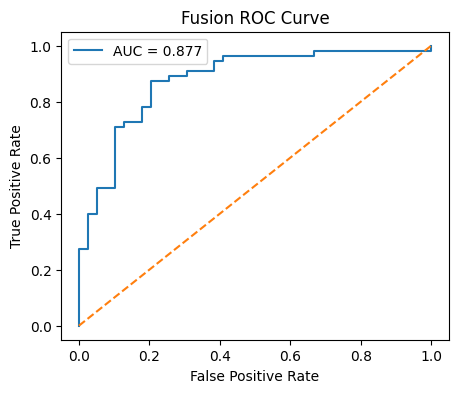

In [62]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_true, fused_probs)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fusion ROC Curve")
plt.legend()
plt.show()


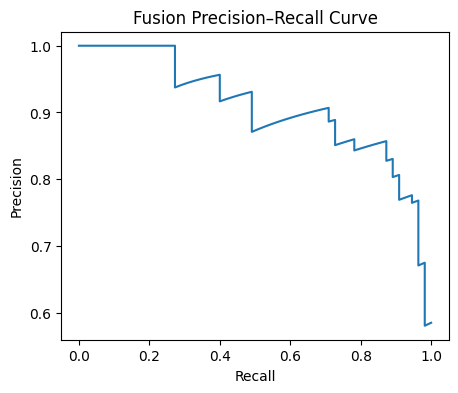

In [63]:
from sklearn.metrics import precision_recall_curve

prec_curve, rec_curve, _ = precision_recall_curve(y_true, fused_probs)

plt.figure(figsize=(5,4))
plt.plot(rec_curve, prec_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Fusion Precision–Recall Curve")
plt.show()


In [64]:
import pandas as pd

fusion_df = pd.DataFrame({
    "id": sorted(common_ids),
    "fused_prob": fused_probs,
    "fused_pred": fused_preds,
    "y_true": y_true
})

fusion_df.to_csv(f"{FUSION_OUT}/fusion_results.csv", index=False)
